In [6]:
import pandas as pd

df = pd.read_csv("../data/Orbit.csv")

# Removes missing values
df = df.dropna()

# Removes infinite values
df = df.replace([float("inf"), float("-inf")], pd.NA).dropna()

# Removing near-collision points where forces explode
# when r gets very small, forces get very large, which could ruin training
df = df[(df["x"]**2 + df["y"]**2) > 0.001]

print(df.head())
print(df.describe())

       time         x         y        vx        vy  NetForce_x  NetForce_y  \
0  0.398999  0.392030  0.454054 -0.982159  0.848508   -2.018950   -1.908290   
1  1.433000 -0.685101  0.077662 -0.328857 -1.219340    2.115000   -0.426293   
2  2.467000 -0.189043 -0.875990  0.952783 -0.376964    0.333185    1.222990   
3  3.501000  0.731798 -0.680278  0.656004  0.663039   -0.705096    0.715634   
4  4.535000  0.939208  0.230915 -0.311395  0.940108   -1.041230   -0.203838   

   SatelliteMass  CentralMass  
0              1          100  
1              1          100  
2              1          100  
3              1          100  
4              1          100  
             time           x           y          vx          vy  NetForce_x  \
count  752.000000  752.000000  752.000000  752.000000  752.000000  752.000000   
mean   376.043909    1.478719   -1.933691    0.001596    0.004543   -0.001406   
std    217.193693    2.847324    2.919020    0.370788    0.376314    0.157236   
min      

In [7]:
features = ["x", "y", "SatelliteMass", "CentralMass"]
targets = ["NetForce_x", "NetForce_y"]

X = df[features].values
y = df[targets].values

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scaling the features and targets to ensure they have a small range of values

X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fitting and transforming the data to scaler
X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [10]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Feeds the data to the model in mini-batches of 64, shuffling the training data for better generalization
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [ ]:
import torch.nn as nn

class ForceNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Defining a simple feedforward neural network with two hidden layers and ReLU activation functions
        self.net = nn.Sequential(
            nn.Linear(4, 64), # 4 inputs -> 64 outputs (hidden)
            nn.ReLU(),
            nn.Linear(64, 64), # 64 inputs (from previous layer) -> 64 outputs (hidden)
            nn.ReLU(),
            nn.Linear(64, 2) # 64 inputs (from previous layer) -> 2 outputs (NetForce_x, NetForce_y)
        )

    # Forward pass through the network (x is the input tensor)
    def forward(self, x):
        return self.net(x)

In [ ]:
model = ForceNet()

loss_fn = nn.MSELoss() # Mean Squared Error loss function for regression tasks
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Adam optimizer with a learning rate of 0.001

epochs = 100

for epoch in range(epochs):
    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:
        pred = model(X_batch)

        loss = loss_fn(pred, y_batch)

        # Before every backpropagation step, I zero the gradients to prevent accumulation from previous steps
        optimizer.zero_grad()
        # Automatically computes the gradients of the loss with respect to the model parameters
        loss.backward()
        # Adam optimizer updates the model parameters based on the computed gradients
        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss:.4f}")

Epoch 0, Loss: 9.8913
Epoch 10, Loss: 7.4785
Epoch 20, Loss: 6.5549
Epoch 30, Loss: 5.8194
Epoch 40, Loss: 4.9973
Epoch 50, Loss: 4.3586
Epoch 60, Loss: 3.7511
Epoch 70, Loss: 3.3165
Epoch 80, Loss: 2.8676
Epoch 90, Loss: 2.5656


In [ ]:
model.eval()

# Turning off gradient tracking for evaluation to save memory and computations
with torch.no_grad():
    predictions = model(X_test)
    test_loss = loss_fn(predictions, y_test)

print("Test loss:", test_loss.item())

Test loss: 0.19326600432395935


In [19]:
pred_real = y_scaler.inverse_transform(predictions.numpy())
y_real = y_scaler.inverse_transform(y_test.numpy())
print("Predictions (real scale):", pred_real[:5])
print("Actual (real scale):", y_real[:5])

Predictions (real scale): [[-0.0252048  -0.00659134]
 [-0.02864259 -0.03575226]
 [-0.02217473  0.02475276]
 [-0.18918344 -0.13306548]
 [ 0.17468408  0.04082471]]
Actual (real scale): [[-0.0334676  -0.00104968]
 [-0.0469096  -0.0363914 ]
 [-0.00521647  0.0243794 ]
 [-0.167552   -0.11839   ]
 [ 0.11810499  0.0451794 ]]


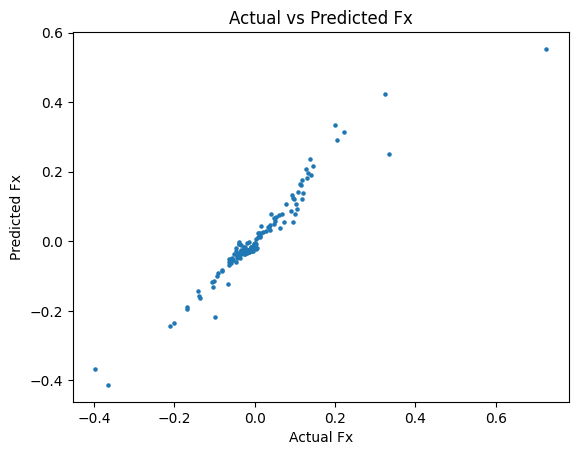

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_real[:, 0], pred_real[:, 0], s=5)
plt.xlabel("Actual Fx")
plt.ylabel("Predicted Fx")
plt.title("Actual vs Predicted Fx")
plt.show()